# 02 — House Price Neural Network (USA Real Estate)

**INTELLIGENT SYSTEM DEVELOPMENT — ASSIGNMENT 03: NEURAL NETWORKS AND REPRESENTATION LEARNING**

Notebook giải bài toán hồi quy giá nhà trên USA Real Estate Dataset. Dữ liệu thô có **2.226.382** dòng; thí nghiệm chính dùng cùng một mẫu ngẫu nhiên tái lập gồm **400.000** dòng cho Linear Regression, Decision Tree, Random Forest và MLP PyTorch.

Mục tiêu không chỉ là so sánh độ chính xác mà còn kiểm tra liệu biểu diễn ẩn của MLP có làm giá nhà dễ giải mã tuyến tính hơn biểu diễn tabular đã tiền xử lý hay không. Kết luận bên dưới luôn phân biệt rõ kết quả validation dùng để chọn mô hình với test chỉ dùng cho đánh giá cuối.

> Notebook này đã được chạy FULL và lưu output. Phần diễn giải hiện tại đọc trực tiếp các output đã lưu; không tái huấn luyện hay thay đổi kết quả thực nghiệm.

## Nguyên tắc train / validation / test và kiểm soát rò rỉ dữ liệu

Dữ liệu được chia cố định thành train/validation/test theo tỷ lệ 70/15/15. Mọi tham số học từ dữ liệu — median để điền khuyết, chuẩn hóa đặc trưng, danh mục one-hot, trung bình/độ lệch chuẩn của log-target và giới hạn safeguard — đều chỉ được fit hoặc suy ra từ **training set**.

Validation dùng để so sánh ba cấu hình MLP và chọn cấu hình theo RMSE rồi MAE. Test không tham gia chọn kiến trúc, learning rate hay epoch; nó chỉ được mở ở bước đánh giá cuối. Cách tổ chức này hạn chế optimistic bias và không dùng target validation/test để đặt clipping bounds.

## Ước lượng chi phí tính toán

FULL mode quét toàn bộ 2.226.382 dòng nhưng chỉ giữ mẫu modeling 400.000 dòng. Sau split, mô hình học trên 280.000 dòng, validation và test mỗi tập 60.000 dòng. Biểu diễn sau tiền xử lý chỉ có 61 chiều, các MLP nông dùng batch 512 và tối đa 30 epoch nên phù hợp với CPU.

Output thời gian xác nhận quy mô này hợp lý: ba lần huấn luyện MLP cộng khoảng 15,7 phút; Random Forest khoảng 7,4 phút; Decision Tree khoảng 3,7 giây và Linear Regression dưới 1 giây. Tổng phần mô hình vì thế vẫn có thể nằm dưới mốc 30 phút trên máy đã chạy, chưa kể chênh lệch phần cứng và I/O.

### Thiết lập môi trường và thư viện

Cell sau nạp các thư viện xử lý dữ liệu, trực quan hóa, scikit-learn và PyTorch; đồng thời cố định seed cho Python, NumPy và Torch. Seed giúp việc lấy mẫu, chia dữ liệu và khởi tạo mô hình có thể tái lập trong cùng môi trường, nhưng không đồng nghĩa mọi nền tảng/phần cứng sẽ cho bitwise-identical result.

In [1]:
from pathlib import Path
import copy
import json
import random
import time
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Markdown, display
from sklearn import metrics
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.model_selection import train_test_split
from torch import nn
from torch.utils.data import DataLoader, Dataset, TensorDataset

pd.set_option("display.max_columns", 100)
warnings.filterwarnings("ignore", category=FutureWarning)

def save_figure(output_path, *args, **kwargs):
    """Không ghi figure QUICK_MODE vào thư mục kết quả final."""
    if QUICK_MODE:
        print(f"QUICK_MODE: không lưu figure final {output_path}")
        return
    plt.savefig(output_path, *args, **kwargs)


### Kết quả thiết lập

Cell hoàn tất mà không báo lỗi. Các thư viện cần thiết đã sẵn sàng và seed chung được thiết lập trước mọi thao tác ngẫu nhiên. Đây là điều kiện nền cho việc so sánh công bằng giữa các mô hình trên cùng dữ liệu.

### Cấu hình thí nghiệm

Cell khai báo các hằng số điều khiển pipeline. Lần chạy đã lưu dùng `QUICK_MODE=False`, mẫu modeling 400.000 dòng, batch size 512, tối đa 30 epoch, patience 6 và `USE_LOG_TARGET=True`. Các giá trị này là cấu hình thực nghiệm đã chạy, không phải đề xuất hậu nghiệm.

In [2]:
RANDOM_STATE = 42
QUICK_MODE = False
RUN_OPTIONAL_DIAGNOSTICS = False
RUN_SEED_STABILITY = False

DATA_RELATIVE_PATH = Path("data/house_price/realtor-data.zip.csv")
MODEL_SAMPLE_SIZE = 400_000 if not QUICK_MODE else 5_000
EXPECTED_RAW_ROWS = 2_226_382
CHUNK_SIZE = 250_000
BATCH_SIZE = 512 if not QUICK_MODE else 128
EPOCHS = 30 if not QUICK_MODE else 2
PATIENCE = 6 if not QUICK_MODE else 2
USE_LOG_TARGET = True
NUM_WORKERS = 0

def set_seed(seed=RANDOM_STATE):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def find_repo_root(relative_data_path):
    start = Path.cwd().resolve()
    for candidate in [start, *start.parents]:
        if (candidate / relative_data_path).exists():
            return candidate
    raise FileNotFoundError(f"Không tìm thấy {relative_data_path} từ {start}")

set_seed()
REPO_ROOT = find_repo_root(DATA_RELATIVE_PATH)
DATA_PATH = REPO_ROOT / DATA_RELATIVE_PATH
MODEL_DIR = REPO_ROOT / "models" / "assignment03" / "house_price"
FIGURE_DIR = REPO_ROOT / "figures" / "assignment03" / "house_price"
RESULT_DIR = REPO_ROOT / "results" / "assignment03"
for directory in (MODEL_DIR, FIGURE_DIR, RESULT_DIR):
    directory.mkdir(parents=True, exist_ok=True)

print({"quick_mode": QUICK_MODE, "data": str(DATA_PATH), "model_dir": str(MODEL_DIR)})

{'quick_mode': False, 'data': 'E:\\WINDOW\\Project\\intelligent-system-assignment-01\\data\\house_price\\realtor-data.zip.csv', 'model_dir': 'E:\\WINDOW\\Project\\intelligent-system-assignment-01\\models\\assignment03\\house_price'}


### Diễn giải cấu hình FULL

Output xác nhận raw dataset kỳ vọng 2.226.382 dòng, đọc theo chunk 250.000 và lấy mẫu tái lập 400.000 dòng. Log-target được bật để giảm độ lệch phải của giá khi tối ưu; metric cuối vẫn được đưa về USD. Ba MLP chỉ khác độ sâu hoặc learning rate như khai báo về sau.

### Thiết bị tính toán

Cell chọn CUDA nếu khả dụng, nếu không dùng CPU. Việc ghi lại device giúp diễn giải thời gian chạy và tránh suy đoán rằng kết quả được tăng tốc bằng GPU.

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device_info = {"device": str(device), "cuda_available": torch.cuda.is_available()}
if torch.cuda.is_available():
    device_info["gpu_name"] = torch.cuda.get_device_name(0)
print(device_info)

{'device': 'cpu', 'cuda_available': False}


### Thiết bị thực tế

Output cho thấy `device='cpu'` và CUDA không khả dụng. Vì vậy các thời gian huấn luyện được báo trong notebook là thời gian CPU; chúng không nên được dùng như benchmark phần cứng tổng quát.

### Kiểm tra schema và dữ liệu thô

Cell đọc một phần dữ liệu để xác minh đường dẫn, tên cột và kiểu dữ liệu trước khi quét toàn bộ file. Target là `price`; các cột gốc gồm thông tin số, địa lý, trạng thái và ngày bán trước đó.

In [4]:
preview = pd.read_csv(DATA_PATH, nrows=5_000 if QUICK_MODE else 20_000)
TARGET = "price"
required = {"price", "bed", "bath", "acre_lot", "house_size", "state", "status"}
assert required.issubset(preview.columns), required - set(preview.columns)
print("Columns:", preview.columns.tolist())
display(preview.head())
display(pd.DataFrame({"dtype": preview.dtypes.astype(str), "missing_pct_sample": preview.isna().mean().mul(100), "nunique_sample": preview.nunique(dropna=False)}))

Columns: ['brokered_by', 'status', 'price', 'bed', 'bath', 'acre_lot', 'street', 'city', 'state', 'zip_code', 'house_size', 'prev_sold_date']


,brokered_by,status,price,bed,bath,acre_lot,street,city,state,zip_code,house_size,prev_sold_date
0,103378.0,for_sale,105000.0,3.0,2.0,0.12,1962661.0,Adjuntas,Puerto Rico,601.0,920.0,NaN
1,52707.0,for_sale,80000.0,4.0,2.0,0.08,1902874.0,Adjuntas,Puerto Rico,601.0,1527.0,NaN
2,103379.0,for_sale,67000.0,2.0,1.0,0.15,1404990.0,Juana Diaz,Puerto Rico,795.0,748.0,NaN
3,31239.0,for_sale,145000.0,4.0,2.0,0.10,1947675.0,Ponce,Puerto Rico,731.0,1800.0,NaN
4,34632.0,for_sale,65000.0,6.0,2.0,0.05,331151.0,Mayaguez,Puerto Rico,680.0,NaN,NaN


,dtype,missing_pct_sample,nunique_sample
brokered_by,float64,0.030,3262
status,str,0.000,2
price,float64,0.000,2574
bed,float64,19.315,34
bath,float64,19.105,30
acre_lot,float64,18.250,1694
street,float64,0.310,19622
city,str,0.080,687
state,str,0.000,12
zip_code,float64,0.140,980


### Schema quan sát được

Dữ liệu có 12 cột: `brokered_by`, `status`, `price`, `bed`, `bath`, `acre_lot`, `street`, `city`, `state`, `zip_code`, `house_size`, `prev_sold_date`. Preview cho thấy dữ liệu hỗn hợp numeric/categorical và có missing value, nên cần pipeline tiền xử lý thay vì đưa trực tiếp vào mô hình.

## Memory-safe raw inspection và modeling sample

Pipeline phân biệt hai mục đích: quét toàn bộ file để audit quy mô/chất lượng, và lấy mẫu ngẫu nhiên tái lập để huấn luyện trong giới hạn tài nguyên. Việc dùng mẫu không làm dataset “biến thành” 400.000 dòng; mọi kết luận mô hình chỉ đại diện cho mẫu modeling đã chọn từ 2,226 triệu listing.

### Lưu ý về thời gian thực thi

Cell quét theo chunk nên tránh nạp đồng thời toàn bộ CSV vào RAM. Random mask với seed cố định tạo mẫu có thể tái lập. Đây là bước I/O lớn nhất ngoài huấn luyện; notebook đã chạy xong nên phần Markdown chỉ phân tích output đã lưu.

### Quét dữ liệu, audit thiếu và tạo mẫu

Cell chỉ giữ bảy cột phục vụ mô hình: bốn numeric (`bed`, `bath`, `acre_lot`, `house_size`), hai categorical (`state`, `status`) và target `price`. Các trường `street`, `city`, `zip_code`, `brokered_by` vẫn được audit nhưng không đưa vào mô hình vì cardinality cao và chi phí one-hot lớn.

In [5]:
MODEL_COLUMNS = ["bed", "bath", "acre_lot", "house_size", "state", "status", "price"]
PROFILE_COLUMNS = MODEL_COLUMNS + ["street", "city", "zip_code", "brokered_by"]
rng = np.random.default_rng(RANDOM_STATE)
sampling_fraction = min(1.0, 1.35 * MODEL_SAMPLE_SIZE / EXPECTED_RAW_ROWS)
raw_rows = 0; missing_counts = pd.Series(0, index=PROFILE_COLUMNS, dtype="int64")
invalid_counts = {"price_le_0": 0, "house_size_le_0": 0, "bed_lt_0": 0, "bath_lt_0": 0, "acre_lot_lt_0": 0}
candidate_parts = []
reader = pd.read_csv(DATA_PATH, usecols=PROFILE_COLUMNS, chunksize=CHUNK_SIZE, nrows=5_000 if QUICK_MODE else None)
for chunk in reader:
    raw_rows += len(chunk); missing_counts = missing_counts.add(chunk.isna().sum(), fill_value=0)
    invalid_counts["price_le_0"] += int((chunk["price"] <= 0).sum()); invalid_counts["house_size_le_0"] += int((chunk["house_size"] <= 0).sum())
    invalid_counts["bed_lt_0"] += int((chunk["bed"] < 0).sum()); invalid_counts["bath_lt_0"] += int((chunk["bath"] < 0).sum()); invalid_counts["acre_lot_lt_0"] += int((chunk["acre_lot"] < 0).sum())
    keep = rng.random(len(chunk)) < (1.0 if QUICK_MODE else sampling_fraction)
    candidate_parts.append(chunk.loc[keep, MODEL_COLUMNS])
candidate_df = pd.concat(candidate_parts, ignore_index=True)
valid_mask = candidate_df["price"].notna() & candidate_df["price"].gt(0)
valid_mask &= candidate_df["house_size"].isna() | candidate_df["house_size"].gt(0)
for feature in ["bed", "bath", "acre_lot"]:
    valid_mask &= candidate_df[feature].isna() | candidate_df[feature].ge(0)
candidate_df = candidate_df.loc[valid_mask]
model_df = candidate_df.sample(n=min(MODEL_SAMPLE_SIZE, len(candidate_df)), random_state=RANDOM_STATE).reset_index(drop=True)
print("Actual raw shape:", (raw_rows, len(preview.columns))); display(missing_counts.rename("missing_count").to_frame()); print("Invalid:", invalid_counts); print("Modeling sample:", model_df.shape)

Actual raw shape: (2226382, 12)


,missing_count
acre_lot,325589
bath,511771
bed,481317
brokered_by,4533
city,1407
house_size,568484
price,1541
state,8
status,0
street,10866


Invalid: {'price_le_0': 280, 'house_size_le_0': 0, 'bed_lt_0': 0, 'bath_lt_0': 0, 'acre_lot_lt_0': 0}
Modeling sample: (400000, 7)


### Kết quả audit dữ liệu thô

Shape đầy đủ là **(2.226.382, 12)**; mẫu modeling có **(400.000, 7)**. Missing value tập trung ở `house_size` (568.484), `bath` (511.771), `bed` (481.317) và `acre_lot` (325.589); `price` thiếu 1.541 dòng. Audit còn ghi nhận 280 giá không dương, trong khi không thấy giá trị âm ở bốn biến vật lý đã kiểm tra.

Các con số này giải thích vì sao pipeline cần lọc target hợp lệ và impute feature. Chúng cũng cho thấy không nên diễn giải mẫu huấn luyện như toàn bộ dữ liệu thô.

### Phân phối biến số và tác dụng của log-target

Cell báo các quantile trên mẫu 400.000 dòng và đặt histogram giá gốc cạnh `log1p(price)`. Trục giá gốc được giới hạn hiển thị ở percentile 99 để phần lớn quan sát không bị vài ngoại lệ cực lớn che khuất; đây chỉ là clipping cho **đồ thị**, không phải thay đổi dữ liệu huấn luyện.

,0.00,0.01,0.25,0.50,0.75,0.99,1.00
price,1.0,10000.00,165000.00,325000.00,550000.00,3.900000e+06,2.125000e+08
bed,1.0,1.00,3.00,3.00,4.00,7.000000e+00,4.440000e+02
bath,1.0,1.00,2.00,2.00,3.00,6.000000e+00,2.220000e+02
acre_lot,0.0,0.02,0.15,0.26,0.99,9.768260e+01,1.000000e+05
house_size,100.0,600.00,1300.00,1756.00,2411.00,6.470000e+03,1.040400e+09


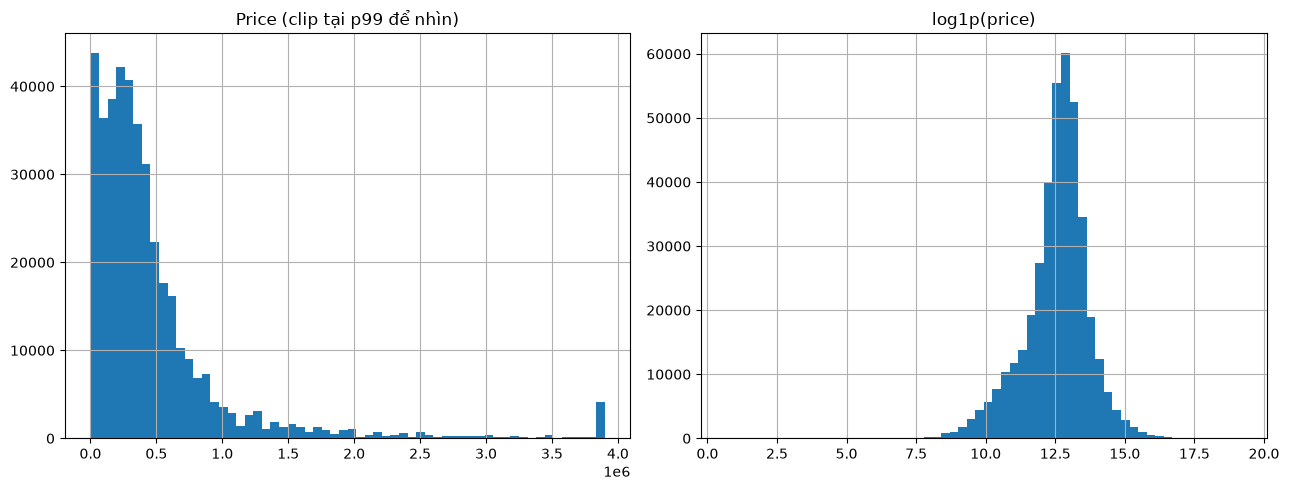

In [6]:
display(model_df[["price", "bed", "bath", "acre_lot", "house_size"]].quantile([0, .01, .25, .5, .75, .99, 1]).T)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
model_df["price"].clip(upper=model_df["price"].quantile(.99)).hist(bins=60, ax=axes[0]); axes[0].set_title("Price (clip tại p99 để nhìn)")
np.log1p(model_df["price"]).hist(bins=60, ax=axes[1]); axes[1].set_title("log1p(price)")
plt.tight_layout(); save_figure(FIGURE_DIR / "price_and_log_price.png", dpi=160, bbox_inches="tight"); plt.show()

### Nhận xét từ quantile và histogram

Giá có median 325.000 USD, percentile 99 là 3,9 triệu USD nhưng max đạt 212,5 triệu USD: phân phối lệch phải rất mạnh. `house_size` cũng có max hơn 1,04 tỷ và `bed`/`bath` có các giá trị 444/222, gợi ý outlier hoặc lỗi nhập liệu.

Histogram xác nhận `log1p(price)` nén đuôi phải và tạo phân phối cân đối hơn quanh vùng log khoảng 12–13. Đây là lý do hợp lý để tối ưu trên log-target, nhưng hình vẽ không tự chứng minh log-transform luôn cải thiện metric USD hay xử lý được mọi outlier.

## Split và prepared representation

Mẫu modeling được chia trước khi fit preprocessing. Train có 280.000 dòng, validation 60.000 và test 60.000. Vì đây là regression nên split không stratify; thay vào đó notebook so sánh quantile target giữa ba tập để kiểm tra độ tương đồng thực nghiệm.

### Chia dữ liệu và kiểm tra target

Cell tạo split 70/15/15 bằng random state cố định. Nếu bật log-target, `y_train_model`, `y_val_model`, `y_test_model` là `log1p(price)`; bản USD vẫn được giữ riêng cho đánh giá dễ hiểu.

In [7]:
X_raw = model_df.drop(columns=TARGET); y_dollar = model_df[TARGET].astype("float64")
X_train_raw, X_temp_raw, y_train_dollar, y_temp_dollar = train_test_split(X_raw, y_dollar, test_size=.30, random_state=RANDOM_STATE)
X_val_raw, X_test_raw, y_val_dollar, y_test_dollar = train_test_split(X_temp_raw, y_temp_dollar, test_size=.50, random_state=RANDOM_STATE)
transform_target = np.log1p if USE_LOG_TARGET else (lambda x: np.asarray(x))
inverse_target = np.expm1 if USE_LOG_TARGET else (lambda x: np.asarray(x))
y_train_model = transform_target(y_train_dollar); y_val_model = transform_target(y_val_dollar); y_test_model = transform_target(y_test_dollar)
for name, values in [("train", y_train_dollar), ("validation", y_val_dollar), ("test", y_test_dollar)]: print(name, len(values), values.quantile([.5,.9,.99]).to_dict())

train 280000 {0.5: 325000.0, 0.9: 949000.0, 0.99: 3900000.0}
validation 60000 {0.5: 325000.0, 0.9: 940000.0, 0.99: 3895030.000000006}
test 60000 {0.5: 325000.0, 0.9: 930000.0, 0.99: 3850000.0}


### Kết quả split

Ba tập có phân phối giá khá gần nhau: median đều 325.000 USD; percentile 90 lần lượt khoảng 949.000, 940.000 và 930.000 USD; percentile 99 khoảng 3,90, 3,895 và 3,85 triệu USD. Điều này không loại bỏ mọi sampling variance ở đuôi cực trị, nhưng không cho thấy lệch phân phối lớn ở các quantile được báo.

### Pipeline tiền xử lý không rò rỉ

Numeric được điền bằng median rồi StandardScaler. Categorical được điền mode rồi OneHotEncoder với `handle_unknown='ignore'`. Toàn bộ transformer chỉ `fit` trên train; validation/test chỉ gọi `transform`, nên thống kê và vocabulary của hai tập giữ lại không chảy ngược vào huấn luyện.

In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_features = ["bed", "bath", "acre_lot", "house_size"]
categorical_features = ["state", "status"]
preprocessor = ColumnTransformer([
    ("numeric", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), numeric_features),
    ("categorical", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False, dtype=np.float32))]), categorical_features),
], verbose_feature_names_out=False)
X_train = preprocessor.fit_transform(X_train_raw).astype("float32")
X_val = preprocessor.transform(X_val_raw).astype("float32"); X_test = preprocessor.transform(X_test_raw).astype("float32")
prepared_feature_names = preprocessor.get_feature_names_out()
print("Prepared shapes:", X_train.shape, X_val.shape, X_test.shape)
display(pd.DataFrame(X_train[:1], columns=prepared_feature_names))

Prepared shapes: (280000, 61) (60000, 61) (60000, 61)


,bed,bath,acre_lot,house_size,state_Alabama,state_Alaska,state_Arizona,state_Arkansas,state_California,state_Colorado,state_Connecticut,state_Delaware,state_District of Columbia,state_Florida,state_Georgia,state_Guam,state_Hawaii,state_Idaho,state_Illinois,state_Indiana,state_Iowa,state_Kansas,state_Kentucky,state_Louisiana,state_Maine,state_Maryland,state_Massachusetts,state_Michigan,state_Minnesota,state_Mississippi,state_Missouri,state_Montana,state_Nebraska,state_Nevada,state_New Hampshire,state_New Jersey,state_New Mexico,state_New York,state_North Carolina,state_North Dakota,state_Ohio,state_Oklahoma,state_Oregon,state_Pennsylvania,state_Puerto Rico,state_Rhode Island,state_South Carolina,state_South Dakota,state_Tennessee,state_Texas,state_Utah,state_Vermont,state_Virgin Islands,state_Virginia,state_Washington,state_West Virginia,state_Wisconsin,state_Wyoming,status_for_sale,status_ready_to_build,status_sold
0,0.624464,0.497706,-0.018677,-0.001213,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


### Biểu diễn sau tiền xử lý

Shape lần lượt là **(280.000, 61)**, **(60.000, 61)** và **(60.000, 61)**. Như vậy đầu vào thực tế của mọi mô hình có `d=61`, gồm bốn numeric đã scale và các cột one-hot từ `state`, `status`.

Một hàng minh họa cho thấy các giá trị liên tục đứng trước vector chỉ báo thưa. `handle_unknown='ignore'` giúp category chỉ xuất hiện ngoài train không làm pipeline lỗi, dù thông tin đó sẽ được biểu diễn bằng các số 0 tương ứng.

## Ba traditional regression baselines

Linear Regression kiểm tra quan hệ tuyến tính trên prepared input; Decision Tree biểu diễn các phân hoạch phi tuyến; Random Forest trung bình hóa nhiều cây để giảm phương sai. Cả ba dùng cùng split và cùng feature matrix với MLP, nên khác biệt metric chủ yếu phản ánh mô hình chứ không phải dữ liệu đầu vào khác nhau.

### Metric hồi quy và audit inverse log-target

Cell định nghĩa một đường đánh giá minh bạch gồm hai lớp. Nếu inverse trực tiếp của raw prediction hữu hạn, notebook báo thêm `raw_mae`, `raw_mse`, `raw_rmse`, `raw_r2`. Song song, metric chính dùng safeguard học **chỉ từ min/max của `y_train_model`**: đếm prediction dưới/trên bounds và non-finite, thay thế non-finite an toàn, clip trên model scale, rồi mới `expm1` về USD.

Các trường audit là `n_below`, `n_above`, `n_nonfinite`, `n_clipped`, `clip_rate`, `clip_lower_train_scale`, `clip_upper_train_scale` và `raw_metrics_valid`. Train-range clipping là **post-processing/domain safeguard có thể tác động metric**, không phải phép biến đổi trung tính. Nếu clip rate vượt 1%, code phát cảnh báo rằng MAE/RMSE/R² sau clipping không phản ánh đầy đủ raw model predictions; ngay cả tỷ lệ thấp hơn cũng cần đọc cùng raw metrics vì một ngoại lệ lớn có thể chi phối MSE/RMSE.

MAE là sai số tuyệt đối trung bình theo USD; RMSE cũng theo USD nhưng bình phương sai số trước khi lấy căn nên phạt lỗi lớn mạnh hơn. R² so mô hình với baseline luôn dự đoán mean target: R² âm nghĩa là kém baseline đó trên tập đánh giá, **không phải accuracy âm**. `raw_metrics_valid=True` chỉ xác nhận inverse và phép tính raw còn an toàn trong float64; nó không nói raw predictions là hợp lý.

In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

CLIP_RATE_WARNING_THRESHOLD = 0.01

def _regression_metric_values(y_true_dollar, prediction_dollar, prefix=""):
    mse = mean_squared_error(y_true_dollar, prediction_dollar)
    return {
        f"{prefix}mae": mean_absolute_error(y_true_dollar, prediction_dollar),
        f"{prefix}mse": mse,
        f"{prefix}rmse": np.sqrt(mse),
        f"{prefix}r2": r2_score(y_true_dollar, prediction_dollar),
    }

def inverse_predictions_with_audit(prediction_model_scale, y_true_dollar=None):
    raw_values = np.asarray(prediction_model_scale, dtype=np.float64).reshape(-1)
    train_values = np.asarray(y_train_model, dtype=np.float64).reshape(-1)
    lower, upper = float(np.min(train_values)), float(np.max(train_values))
    finite_mask = np.isfinite(raw_values)

    n_below = int(np.sum(finite_mask & (raw_values < lower)))
    n_above = int(np.sum(finite_mask & (raw_values > upper)))
    n_nonfinite = int(np.sum(~finite_mask))
    n_clipped = n_below + n_above + n_nonfinite
    clip_rate = n_clipped / len(raw_values) if len(raw_values) else 0.0

    # Raw inverse chỉ được tính nếu cả expm1 và tổng squared error an toàn cho float64.
    raw_prediction_dollar = None
    raw_metrics_valid = False
    if len(raw_values) and n_nonfinite == 0:
        metric_safe_limit = np.sqrt(np.finfo(np.float64).max / len(raw_values)) * 0.25
        inverse_safe = (not USE_LOG_TARGET) or bool(np.all(raw_values <= np.log1p(metric_safe_limit)))
        if inverse_safe:
            with np.errstate(over="ignore", invalid="ignore"):
                candidate = np.asarray(inverse_target(raw_values), dtype=np.float64)
            residual_safe = y_true_dollar is None or bool(
                np.all(np.isfinite(candidate - np.asarray(y_true_dollar, dtype=np.float64)))
                and np.all(np.abs(candidate - np.asarray(y_true_dollar, dtype=np.float64)) <= metric_safe_limit)
            )
            if np.all(np.isfinite(candidate)) and residual_safe:
                raw_prediction_dollar = candidate
                raw_metrics_valid = True

    # Safeguard dùng duy nhất thống kê train; replacement và clipping đều được audit.
    safeguarded_values = np.nan_to_num(
        raw_values,
        nan=float(np.mean(train_values)),
        posinf=upper,
        neginf=lower,
    )
    safeguarded_values = np.clip(safeguarded_values, lower, upper)
    safeguarded_prediction_dollar = np.maximum(
        0.0,
        np.asarray(inverse_target(safeguarded_values), dtype=np.float64),
    )
    audit = {
        "raw_metrics_valid": raw_metrics_valid,
        "n_below": n_below,
        "n_above": n_above,
        "n_nonfinite": n_nonfinite,
        "n_clipped": n_clipped,
        "clip_rate": clip_rate,
        "clip_lower_train_scale": lower,
        "clip_upper_train_scale": upper,
    }
    return raw_prediction_dollar, safeguarded_prediction_dollar, audit

def regression_metrics(y_true_dollar, prediction_model_scale):
    raw_prediction, safeguarded_prediction, audit = inverse_predictions_with_audit(
        prediction_model_scale,
        y_true_dollar=y_true_dollar,
    )
    result = _regression_metric_values(y_true_dollar, safeguarded_prediction)
    if raw_prediction is None:
        result.update({"raw_mae": np.nan, "raw_mse": np.nan, "raw_rmse": np.nan, "raw_r2": np.nan})
    else:
        result.update(_regression_metric_values(y_true_dollar, raw_prediction, prefix="raw_"))
    result.update(audit)
    return result

def report_clipping(result_table, context, label_column):
    audit_columns = [label_column, "n_below", "n_above", "n_nonfinite", "n_clipped", "clip_rate", "raw_metrics_valid"]
    display(result_table[audit_columns])
    significant = result_table.loc[result_table["clip_rate"] > CLIP_RATE_WARNING_THRESHOLD]
    if len(significant):
        labels = ", ".join(significant[label_column].astype(str))
        display(Markdown(
            f"⚠️ **Cảnh báo clipping ({context}):** {labels} có clip_rate > "
            f"{CLIP_RATE_WARNING_THRESHOLD:.1%}. MAE/RMSE/R² chính là metric sau train-range clipping "
            "và không phản ánh hoàn toàn raw model predictions; hãy ưu tiên đối chiếu các cột raw_* khi raw_metrics_valid=True."
        ))
    elif int(result_table["n_clipped"].sum()) > 0:
        print(f"{context}: có prediction bị safeguard nhưng clip_rate của từng model không vượt 1%.")
    else:
        print(f"{context}: không có prediction nào bị train-range clipping hoặc thay thế non-finite.")

### Lưu ý về chi phí baseline

Random Forest là baseline tốn thời gian nhất vì phải fit nhiều cây trên 280.000 hàng và 61 feature. Output thực tế cho thấy khoảng 441,5 giây, nên việc chạy FULL cần được cân nhắc; lần này kết quả đã được lưu và không được chạy lại.

### Huấn luyện và đánh giá baseline trên validation

Cell fit Linear Regression, Decision Tree và Random Forest trên train, sau đó đánh giá validation bằng cả metric raw (khi an toàn) và metric safeguarded. Bounds `0,693147–19,174453` nằm trên model/log scale và được suy ra duy nhất từ target train.

In [10]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

baseline_models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree Regressor": DecisionTreeRegressor(max_depth=18, min_samples_leaf=10, random_state=RANDOM_STATE),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=20 if QUICK_MODE else 150, max_depth=22, min_samples_leaf=5, n_jobs=-1, random_state=RANDOM_STATE),
}
baseline_rows = []
for name, model in baseline_models.items():
    started = time.perf_counter(); model.fit(X_train, y_train_model); elapsed = time.perf_counter() - started
    baseline_rows.append({"model": name, "split": "validation", **regression_metrics(y_val_dollar, model.predict(X_val)), "training_seconds": elapsed, "parameter_count": np.nan})
baseline_val_results = pd.DataFrame(baseline_rows)
display(baseline_val_results.sort_values("rmse"))
report_clipping(baseline_val_results, "Traditional baselines / validation", "model")

,model,split,mae,mse,rmse,r2,raw_mae,raw_mse,raw_rmse,raw_r2,raw_metrics_valid,n_below,n_above,n_nonfinite,n_clipped,clip_rate,clip_lower_train_scale,clip_upper_train_scale,training_seconds,parameter_count
2,Random Forest Regressor,validation,227886.112494,6.665272e+11,8.164112e+05,0.413258,2.278861e+05,6.665272e+11,8.164112e+05,4.132585e-01,True,0,0,0,0,0.00000,0.693147,19.174453,441.461023,NaN
1,Decision Tree Regressor,validation,240720.367121,7.193498e+11,8.481449e+05,0.366759,2.407204e+05,7.193498e+11,8.481449e+05,3.667589e-01,True,0,0,0,0,0.00000,0.693147,19.174453,3.728985,NaN
0,Linear Regression,validation,327404.313598,8.020761e+12,2.832095e+06,-6.060647,8.608371e+07,4.297405e+20,2.073018e+10,-3.782990e+08,True,0,9,0,9,0.00015,0.693147,19.174453,0.779315,NaN


,model,n_below,n_above,n_nonfinite,n_clipped,clip_rate,raw_metrics_valid
0,Linear Regression,0,9,0,9,0.00015,True
1,Decision Tree Regressor,0,0,0,0,0.00000,True
2,Random Forest Regressor,0,0,0,0,0.00000,True


Traditional baselines / validation: có prediction bị safeguard nhưng clip_rate của từng model không vượt 1%.


### Kết quả validation của baseline

Random Forest tốt nhất trong nhóm truyền thống: MAE **227.886 USD**, RMSE **816.411 USD**, R² **0,4133**, không clipping; thời gian khoảng **441,5 s**. Decision Tree đứng sau với MAE **240.720 USD**, RMSE **848.145 USD**, R² **0,3668**, cũng không clipping nhưng chỉ mất **3,73 s** — một đánh đổi tốc độ/độ chính xác đáng chú ý.

Linear Regression có safeguarded RMSE **2,832 triệu USD**, R² **−6,0606**. Chỉ 9/60.000 dự đoán vượt bound (`clip_rate=0,015%`), nhưng raw RMSE khoảng **20,73 tỷ USD** và raw R² khoảng **−3,78×10⁸**. Cả ba baseline đều có `raw_metrics_valid=True`; RF/Tree có raw=safeguarded vì không clip. Đây là bằng chứng rằng mô hình tuyến tính ngoại suy bệnh lý trên một số hàng; clipping cải thiện mạnh số liệu báo cáo và vì thế tuyệt đối không thể coi là trung tính.

## Tensor/DataLoader và MLP regression

Feature float32 và target chuẩn hóa được chuyển thành TensorDataset/DataLoader. Shuffle chỉ áp dụng cho train; validation/test giữ thứ tự ổn định để prediction khớp chính xác với target khi tính metric và phân tích lỗi.

### Chuẩn hóa target cho tối ưu

Ngoài `log1p`, MLP còn chuẩn hóa log-target bằng mean và standard deviation chỉ từ train. Mục đích là đưa loss về thang số thuận lợi cho gradient descent. Hàm đánh giá đảo chuẩn hóa rồi đảo log để báo MAE/RMSE bằng USD.

In [11]:
target_mean = float(np.mean(y_train_model)); target_std = float(np.std(y_train_model) + 1e-8)
def standardize_y(values): return ((np.asarray(values) - target_mean) / target_std).astype("float32").reshape(-1, 1)
def unstandardize_prediction(values): return np.asarray(values).reshape(-1) * target_std + target_mean
def make_regression_loader(X_array, y_values, shuffle):
    ds = TensorDataset(torch.from_numpy(np.asarray(X_array, dtype=np.float32)), torch.from_numpy(standardize_y(y_values)))
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
train_loader = make_regression_loader(X_train, y_train_model, True); val_loader = make_regression_loader(X_val, y_val_model, False); test_loader = make_regression_loader(X_test, y_test_model, False)
X_batch, y_batch = next(iter(train_loader)); print("X_batch:", X_batch.shape, "y_batch:", y_batch.shape, "target mean/std:", target_mean, target_std)

X_batch: torch.Size([512, 61]) y_batch: torch.Size([512, 1]) target mean/std: 12.546535927497725 1.1601016055052147


### Batch thực tế

Output cho thấy `X_batch` có shape **[512, 61]** và `y_batch` **[512, 1]**, đúng với batch size và một output hồi quy. Mean/std log-target train là khoảng **12,5465/1,1601**. Các thống kê này không dùng validation/test nên không phát sinh target leakage.

## Từ input đến learned representation

MLP ánh xạ `X∈R^(B×61)` qua các hidden layer. Baseline có luồng `61→64→1`: `H1∈R^(B×64)` rồi output `ŷ_model∈R^(B×1)`. Mạng sâu có `61→64→32→1`, với `H2∈R^(B×32)` là representation ngay trước output head.

Sau mỗi hidden Linear là `ReLU(z)=max(0,z)`. Phi tuyến này cho phép mạng mô tả tương tác/ngưỡng phức tạp; nếu chỉ chồng các Linear layer, toàn bộ phép hợp thành vẫn chỉ là một ánh xạ affine. Output cuối là prediction trên standardized log-price model scale, chưa phải USD.

### Output và loss cho regression

Output có shape `[batch_size, 1]` và không dùng activation phân loại. Loss là MSE trên **log-target đã chuẩn hóa**, trong khi tiêu chí báo cáo/chọn cuối là RMSE rồi MAE trên USD sau inverse. Do hai thang đo nhấn mạnh sai số khác nhau, validation loss thấp nhất không nhất thiết cho RMSE USD thấp nhất.

### Backpropagation trong code

Mỗi batch thực hiện forward pass, tính MSE loss, xóa gradient cũ, `backward()` để lan truyền đạo hàm và `optimizer.step()` để cập nhật trọng số. Validation đặt model ở eval mode và không ghi gradient. Early stopping lưu state có validation loss tốt nhất, thay vì mặc nhiên dùng epoch cuối.

### Kiến trúc MLP

Cell định nghĩa MLP tổng quát từ danh sách `hidden_dims`. Mỗi hidden layer gồm Linear và ReLU; linear head cuối cho một giá trị hồi quy. Tùy chọn `return_hidden=True` cho phép trích activation ẩn mà không thay đổi đường dự đoán.

In [12]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dims, output_dim):
        super().__init__()
        layers = []
        previous = input_dim
        for width in hidden_dims:
            layers.extend([nn.Linear(previous, width), nn.ReLU()])
            previous = width
        layers.append(nn.Linear(previous, output_dim))
        self.network = nn.Sequential(*layers)
        self.hidden_dims = tuple(hidden_dims)

    def forward(self, x, return_hidden=False):
        hidden = x
        hidden_states = []
        for layer in self.network[:-1]:
            hidden = layer(hidden)
            if isinstance(layer, nn.ReLU):
                hidden_states.append(hidden)
        output = self.network[-1](hidden)
        return (output, hidden_states[-1]) if return_hidden else output

def count_trainable_parameters(model):
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)

def architecture_summary(model, input_dim, output_dim):
    return {
        "input_dim": input_dim,
        "hidden_dims": model.hidden_dims,
        "output_dim": output_dim,
        "trainable_parameters": count_trainable_parameters(model),
        "model": str(model),
    }

### Số tham số và độ phức tạp

Với input 61 chiều, Baseline MLP `61→64→1` có `(61×64+64)+(64×1+1)=4.033` tham số. Mạng sâu thêm layer `64→32`, nên tổng `(61×64+64)+(64×32+32)+(32×1+1)=6.081`. Bias được cộng một lần cho mỗi output unit.

Đây vẫn là mạng nhỏ; dataset lớn không buộc kiến trúc phải lớn khi input chỉ có 61 chiều. Thời gian chủ yếu đến từ 280.000 hàng, số epoch và forward/backward theo batch hơn là số tham số tuyệt đối.

### Vòng lặp train, validation và đánh giá USD

Cell triển khai một epoch train, một epoch validation, lưu history loss/RMSE, early stopping và khôi phục best state. Hàm đánh giá gom prediction theo đúng thứ tự loader, đảo chuẩn hóa target rồi gọi cùng `regression_metrics`, nên MLP và baseline dùng chung quy tắc inverse/clipping audit.

In [13]:
def evaluate_mlp_regressor(model, loader, y_true_dollar, criterion):
    model.eval(); losses, predictions = [], []
    with torch.no_grad():
        for X_b, y_b in loader:
            X_b, y_b = X_b.to(device), y_b.to(device); output = model(X_b)
            losses.append(criterion(output, y_b).item() * len(y_b)); predictions.extend(output.cpu().numpy().reshape(-1))
    model_scale = unstandardize_prediction(predictions)
    return {"loss": sum(losses) / len(predictions), **regression_metrics(y_true_dollar, model_scale)}

def train_mlp_regressor(config):
    model = MLP(X_train.shape[1], config["hidden_dims"], 1).to(device); criterion = nn.MSELoss(); optimizer = torch.optim.Adam(model.parameters(), lr=config["learning_rate"])
    best_state, best_loss, best_epoch, wait, history = copy.deepcopy(model.state_dict()), float("inf"), 0, 0, []
    started = time.perf_counter()
    for epoch in range(1, config["epochs"] + 1):
        model.train(); total, seen, train_predictions, train_true_model = 0.0, 0, [], []
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(device), y_b.to(device); optimizer.zero_grad(); output = model(X_b); assert X_b.dtype == torch.float32 and output.shape == y_b.shape; assert output.device == X_b.device == next(model.parameters()).device; loss = criterion(output, y_b); loss.backward(); optimizer.step()
            total += loss.item() * len(y_b); seen += len(y_b); train_predictions.extend(output.detach().cpu().numpy().reshape(-1)); train_true_model.extend(unstandardize_prediction(y_b.detach().cpu().numpy()))
        val_result = evaluate_mlp_regressor(model, val_loader, y_val_dollar, criterion)
        train_rmse = regression_metrics(inverse_target(np.asarray(train_true_model)), unstandardize_prediction(train_predictions))["rmse"]
        history.append({"epoch": epoch, "train_loss": total/seen, "val_loss": val_result["loss"], "train_rmse": train_rmse, "val_rmse": val_result["rmse"]})
        if val_result["loss"] < best_loss: best_state, best_loss, best_epoch, wait = copy.deepcopy(model.state_dict()), val_result["loss"], epoch, 0
        else:
            wait += 1
            if wait >= config["patience"]: break
    model.load_state_dict(best_state); elapsed = time.perf_counter() - started
    return model, pd.DataFrame(history), {"best_epoch": best_epoch, "training_seconds": elapsed, **evaluate_mlp_regressor(model, val_loader, y_val_dollar, criterion)}

### Cách đọc history

`train_loss`/`val_loss` đo MSE trên log-target chuẩn hóa; `train_rmse`/`val_rmse` đo sai số USD sau safeguard. Hai cặp curve trả lời hai câu hỏi khác nhau: tối ưu có hội tụ trên thang loss hay không, và sai số tiền tệ thay đổi ra sao. Không nên suy luận overfitting chỉ từ một spike RMSE ở đuôi nặng.

## Required neural-network experiments

Ba cấu hình được chạy trên cùng DataLoader với optimizer Adam: Baseline MLP `[64]`, Deeper MLP `[64,32]` với learning rate `1e-3`, và cùng mạng sâu với `3e-4`. Mỗi cấu hình tối đa 30 epoch, patience 6. So hai mạng sâu là controlled optimization experiment vì kiến trúc/dữ liệu giữ nguyên và chỉ learning rate thay đổi; so Baseline với mạng sâu đồng thời thay đổi độ sâu nên trả lời một câu hỏi khác.

### Lưu ý về thời gian thực thi

Output thực tế: Baseline MLP khoảng **311,5 s**, Deeper `1e-3` khoảng **341,0 s**, Deeper `3e-4` khoảng **286,6 s**. Tổng gần 15,7 phút trên CPU. Chênh lệch thời gian không nên diễn giải thành ưu thế thuật toán tuyệt đối vì còn phụ thuộc scheduling và tải hệ thống.

### Chạy ba cấu hình và chọn bằng validation

Cell lưu model/history cho từng cấu hình, báo parameter count, best epoch, thời gian và metric validation. Quy tắc chọn được khai báo trước: sắp theo safeguarded validation RMSE, sau đó MAE để phá hòa; test hoàn toàn chưa được dùng ở đây.

In [14]:
experiment_configs = [
    {"name":"Baseline MLP", "hidden_dims":[64], "learning_rate":1e-3, "epochs":EPOCHS, "patience":PATIENCE},
    {"name":"Deeper MLP / Adam 1e-3", "hidden_dims":[64,32], "learning_rate":1e-3, "epochs":EPOCHS, "patience":PATIENCE},
    {"name":"Deeper MLP / Adam 3e-4", "hidden_dims":[64,32], "learning_rate":3e-4, "epochs":EPOCHS, "patience":PATIENCE},
]
mlp_models={}; mlp_histories={}; rows=[]
for config in experiment_configs:
    set_seed(); model, history, result = train_mlp_regressor(config); mlp_models[config["name"]]=model; mlp_histories[config["name"]]=history
    rows.append({"experiment":config["name"], "architecture":f"{X_train.shape[1]}→"+"→".join(map(str,config["hidden_dims"]))+"→1", "input_dim":X_train.shape[1], "output_dim":1, "hidden_dims":str(config["hidden_dims"]), "optimizer":"Adam", "learning_rate":config["learning_rate"], "batch_size":BATCH_SIZE, "max_epochs":EPOCHS, "early_stopping_patience":PATIENCE, "parameter_count":count_trainable_parameters(model), **result})
mlp_experiment_results=pd.DataFrame(rows); display(mlp_experiment_results.sort_values("rmse")); report_clipping(mlp_experiment_results, "MLP experiments / validation", "experiment")

,experiment,architecture,input_dim,output_dim,hidden_dims,optimizer,learning_rate,batch_size,max_epochs,early_stopping_patience,parameter_count,best_epoch,training_seconds,loss,mae,mse,rmse,r2,raw_mae,raw_mse,raw_rmse,raw_r2,raw_metrics_valid,n_below,n_above,n_nonfinite,n_clipped,clip_rate,clip_lower_train_scale,clip_upper_train_scale
0,Baseline MLP,61→64→1,61,1,[64],Adam,0.0010,512,30,6,4033,26,311.467724,0.551907,259329.593701,7.956842e+11,892011.334774,0.299562,259329.593701,7.956842e+11,892011.334774,0.299562,True,0,0,0,0,0.0,0.693147,19.174453
1,Deeper MLP / Adam 1e-3,61→64→32→1,61,1,"[64, 32]",Adam,0.0010,512,30,6,6081,30,340.986549,0.547441,258204.014586,8.027227e+11,895947.932132,0.293366,258204.014586,8.027227e+11,895947.932132,0.293366,True,0,0,0,0,0.0,0.693147,19.174453
2,Deeper MLP / Adam 3e-4,61→64→32→1,61,1,"[64, 32]",Adam,0.0003,512,30,6,6081,30,286.648293,0.550897,259084.940745,8.043547e+11,896858.247353,0.291929,259084.940745,8.043547e+11,896858.247353,0.291929,True,0,0,0,0,0.0,0.693147,19.174453


,experiment,n_below,n_above,n_nonfinite,n_clipped,clip_rate,raw_metrics_valid
0,Baseline MLP,0,0,0,0,0.0,True
1,Deeper MLP / Adam 1e-3,0,0,0,0,0.0,True
2,Deeper MLP / Adam 3e-4,0,0,0,0,0.0,True


MLP experiments / validation: không có prediction nào bị train-range clipping hoặc thay thế non-finite.


### Kết quả ba MLP trên validation

Baseline MLP: MAE **259.330 USD**, RMSE **892.011 USD**, R² **0,2996**, best epoch 26. Deeper `1e-3`: MAE **258.204 USD**, RMSE **895.948 USD**, R² **0,2934**, best epoch 30. Deeper `3e-4`: MAE **259.085 USD**, RMSE **896.858 USD**, R² **0,2919**, best epoch 30. Cả ba có `clip_rate=0` và raw metrics hợp lệ, nên kết quả validation không bị safeguard làm thay đổi.

Deeper `1e-3` có validation loss và MAE thấp nhất, nhưng Baseline có RMSE USD thấp nhất nên được chọn đúng theo quy tắc. Thêm hidden layer vì thế **không cải thiện tiêu chí selection**; giảm learning rate từ `1e-3` xuống `3e-4` cũng không cải thiện validation MAE/RMSE/R² trong thí nghiệm có kiểm soát này. Đây là một metric trade-off, không phải mâu thuẫn: loss tối ưu trên standardized log scale, còn lựa chọn ưu tiên squared error trên USD.

### Cách phân tích sau khi chạy

So sánh mô hình phải dựa trên mức độ chênh lệch và độ ổn định, không chỉ thứ hạng. Ba RMSE validation của MLP chỉ cách nhau dưới 5.000 USD trên mức gần 0,9 triệu; một split duy nhất chưa đủ để khẳng định kiến trúc nông vượt trội tổng quát. Việc không chạy seed stability cũng giới hạn sức mạnh của kết luận.

### Learning curves

Cell vẽ song song MSE loss trên standardized log-target và safeguarded RMSE USD. Đường dọc đánh dấu epoch có validation loss tốt nhất của từng cấu hình, tức checkpoint được giữ bởi early stopping.

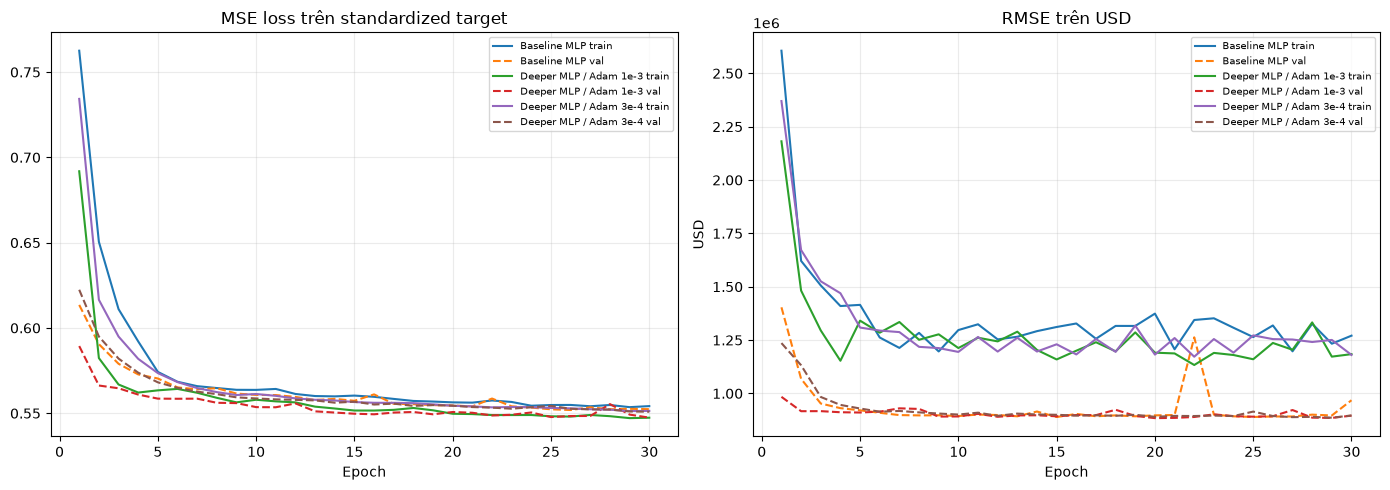

In [15]:
fig, axes=plt.subplots(1,2,figsize=(14,5))
for name,h in mlp_histories.items():
    axes[0].plot(h.epoch,h.train_loss,label=f"{name} train"); axes[0].plot(h.epoch,h.val_loss,"--",label=f"{name} val")
    axes[1].plot(h.epoch,h.train_rmse,label=f"{name} train"); axes[1].plot(h.epoch,h.val_rmse,"--",label=f"{name} val")
axes[0].set(title="MSE loss trên standardized target",xlabel="Epoch"); axes[1].set(title="RMSE trên USD",xlabel="Epoch",ylabel="USD")
for ax in axes: ax.legend(fontsize=7); ax.grid(alpha=.25)
plt.tight_layout(); save_figure(FIGURE_DIR/"mlp_training_curves.png",dpi=160,bbox_inches="tight"); plt.show()

### Hội tụ và dấu hiệu overfitting

Loss giảm nhanh trong vài epoch đầu rồi tiến tới plateau quanh validation loss 0,55. Hai mạng sâu đạt best epoch 30, tức chạm giới hạn epoch trước khi patience kích hoạt; Baseline đạt best epoch 26. Validation curve không tách xa train một cách tăng dần rõ rệt, nên output **không cung cấp bằng chứng mạnh về overfitting cổ điển**.

RMSE USD dao động hơn loss log, gồm một spike của Baseline gần epoch 22. Train RMSE đôi lúc cao hơn validation RMSE; với target đuôi nặng, khác biệt outlier giữa split/batch và phép safeguard có thể chi phối metric USD. Vì vậy đây nên được mô tả là hội tụ kèm nhiễu ở thang USD, không phải khẳng định nhân quả hay overfit chắc chắn.

## Final selection, test và error analysis

Baseline MLP được khóa từ validation trước khi test. Bảng cuối đặt mô hình này cạnh ba baseline truyền thống trên đúng 60.000 mẫu test, báo cả metric raw/safeguarded, clipping audit, thời gian và parameter count khi phù hợp.

### Đánh giá test duy nhất sau selection

Cell khôi phục MLP đã chọn, suy luận test và tạo bảng so sánh. Các metric chính vẫn là sau train-range safeguard; raw metrics được giữ để người đọc thấy chính xác post-processing đã thay đổi kết quả đến đâu.

In [16]:
best_name=mlp_experiment_results.sort_values(["rmse","mae"]).iloc[0].experiment; final_mlp=mlp_models[best_name]; criterion=nn.MSELoss()
mlp_test=evaluate_mlp_regressor(final_mlp,test_loader,y_test_dollar,criterion); test_rows=[]
for name,model in baseline_models.items(): test_rows.append({"model":name,"split":"test",**regression_metrics(y_test_dollar,model.predict(X_test)),"training_seconds":baseline_val_results.set_index("model").loc[name,"training_seconds"],"parameter_count":np.nan,"learned_representation":False})
mlp_metric_fields={key:value for key,value in mlp_test.items() if key != "loss"}
test_rows.append({"model":best_name,"split":"test",**mlp_metric_fields,"training_seconds":mlp_experiment_results.set_index("experiment").loc[best_name,"training_seconds"],"parameter_count":count_trainable_parameters(final_mlp),"learned_representation":True})
model_comparison=pd.DataFrame(test_rows); model_comparison["input_representation"]="Scaled numeric + state/status one-hot"; model_comparison["interpretability"]=np.where(model_comparison.learned_representation,"Phân tán; cần probe","Linear/tree dễ giải thích hơn"); display(Markdown(f"**Final MLP chọn bằng validation:** {best_name}")); display(model_comparison.sort_values("rmse")); report_clipping(model_comparison, "Four-model comparison / test", "model")

**Final MLP chọn bằng validation:** Baseline MLP

,model,split,mae,mse,rmse,r2,raw_mae,raw_mse,raw_rmse,raw_r2,raw_metrics_valid,n_below,n_above,n_nonfinite,n_clipped,clip_rate,clip_lower_train_scale,clip_upper_train_scale,training_seconds,parameter_count,learned_representation,input_representation,interpretability
2,Random Forest Regressor,test,228399.638675,7.106819e+11,8.430195e+05,0.395546,2.283996e+05,7.106819e+11,8.430195e+05,3.955464e-01,True,0,0,0,0,0.000000,0.693147,19.174453,441.461023,NaN,False,Scaled numeric + state/status one-hot,Linear/tree dễ giải thích hơn
1,Decision Tree Regressor,test,240670.836290,7.472008e+11,8.644078e+05,0.364486,2.406708e+05,7.472008e+11,8.644078e+05,3.644861e-01,True,0,0,0,0,0.000000,0.693147,19.174453,3.728985,NaN,False,Scaled numeric + state/status one-hot,Linear/tree dễ giải thích hơn
3,Baseline MLP,test,265720.582887,1.661940e+12,1.289163e+06,-0.413524,2.709222e+05,5.491488e+12,2.343392e+06,-3.670654e+00,True,0,1,0,1,0.000017,0.693147,19.174453,311.467724,4033.0,True,Scaled numeric + state/status one-hot,Phân tán; cần probe
0,Linear Regression,test,345139.240455,1.137018e+13,3.371970e+06,-8.670640,9.746435e+34,5.699579e+74,2.387379e+37,-4.847642e+62,True,0,12,0,12,0.000200,0.693147,19.174453,0.779315,NaN,False,Scaled numeric + state/status one-hot,Linear/tree dễ giải thích hơn


,model,n_below,n_above,n_nonfinite,n_clipped,clip_rate,raw_metrics_valid
0,Linear Regression,0,12,0,12,0.000200,True
1,Decision Tree Regressor,0,0,0,0,0.000000,True
2,Random Forest Regressor,0,0,0,0,0.000000,True
3,Baseline MLP,0,1,0,1,0.000017,True


Four-model comparison / test: có prediction bị safeguard nhưng clip_rate của từng model không vượt 1%.


### Kết quả test và mô hình thắng

**Random Forest thắng rõ ràng** với MAE **228.400 USD**, RMSE **843.020 USD**, R² **0,3955** và không clipping. Decision Tree đứng thứ hai: MAE **240.671 USD**, RMSE **864.408 USD**, R² **0,3645**, cũng không clipping.

Baseline MLP đạt MAE **265.721 USD**, safeguarded RMSE **1,289 triệu USD**, R² **−0,4135**. Một prediction vượt upper bound (`1/60.000`, `clip_rate=0,001667%`); raw RMSE là **2,343 triệu USD** và raw R² **−3,6707**. Linear Regression kém nhất: safeguarded RMSE **3,372 triệu USD**, R² **−8,6706**; 12 mẫu bị clip (`0,02%`), trong khi raw RMSE khoảng **2,39×10³⁷ USD**.

Kết luận test là mô hình cây phù hợp hơn các MLP nông đã thử trên biểu diễn này. Đồng thời, chênh lệch raw/safeguarded cho thấy ngay một clip rất hiếm vẫn có thể thay đổi mạnh RMSE/R² do bình phương sai số; bảng phải luôn được đọc cùng audit, không chỉ nhìn `clip_rate`.

### Phân tích lỗi của MLP đã chọn

Cell tái tạo prediction test của MLP, áp dụng đúng safeguard đã định nghĩa, lập bảng sai số theo quintile giá, liệt kê lỗi tuyệt đối lớn nhất và vẽ actual-versus-predicted cùng residual. Đây là mô tả hành vi trên test đã mở, không được dùng ngược lại để chọn lại mô hình.

,model,raw_metrics_valid,n_below,n_above,n_nonfinite,n_clipped,clip_rate,clip_lower_train_scale,clip_upper_train_scale
0,Baseline MLP,True,0,1,0,1,0.000017,0.693147,19.174453


,model,n_below,n_above,n_nonfinite,n_clipped,clip_rate,raw_metrics_valid
0,Baseline MLP,0,1,0,1,0.000017,True


Final MLP error analysis / test: có prediction bị safeguard nhưng clip_rate của từng model không vượt 1%.


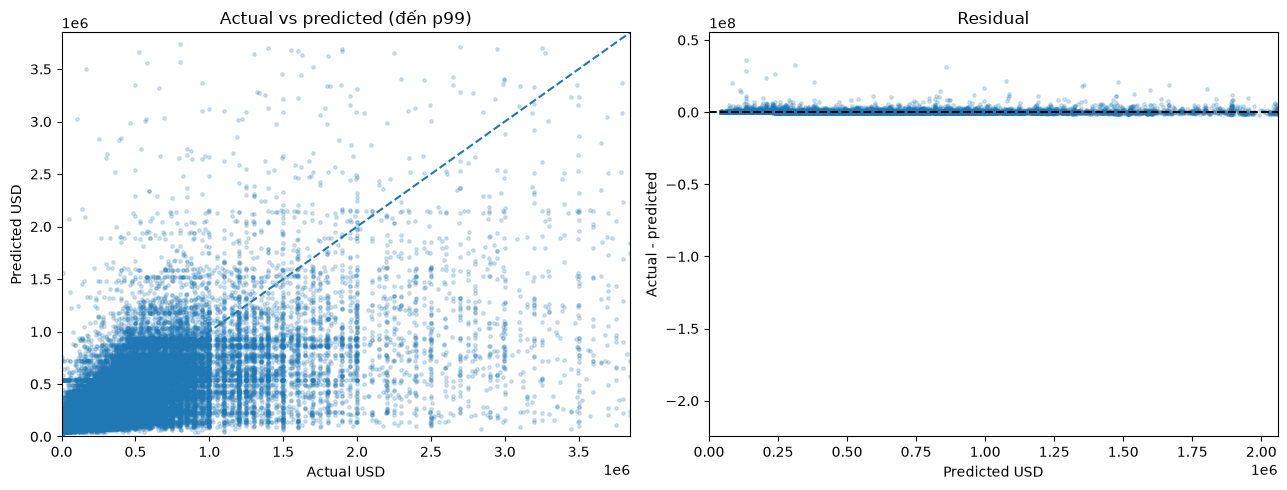

,count,mean,median
price_range,,,
"(0.999, 130000.0]",12133,95216.030053,76051.225976
"(130000.0, 259900.0]",11890,87092.428543,64151.777723
"(259900.0, 397419.4]",11977,122040.597201,103225.734592
"(397419.4, 630000.0]",12027,205353.433759,148451.046169
"(630000.0, 54850000.0]",11973,820260.914115,419857.378546


,bed,bath,acre_lot,house_size,state,status,actual_price,predicted_price,absolute_error,price_range
113165,444.0,222.0,0.34,1700.0,Oregon,for_sale,440000.0,2.125000e+08,2.120600e+08,"(397419.4, 630000.0]"
155924,99.0,1.0,0.69,125.0,Hawaii,for_sale,455000.0,7.924773e+07,7.879273e+07,"(397419.4, 630000.0]"
6750,7.0,14.0,0.57,18169.0,California,for_sale,54850000.0,1.224333e+07,4.260667e+07,"(630000.0, 54850000.0]"
64686,NaN,NaN,0.65,NaN,Florida,for_sale,36000000.0,1.349829e+05,3.586502e+07,"(630000.0, 54850000.0]"
343959,5.0,7.0,3.43,4540.0,New York,for_sale,40000000.0,5.074744e+06,3.492526e+07,"(630000.0, 54850000.0]"
150842,NaN,NaN,6.20,NaN,Washington,for_sale,33000000.0,3.097391e+05,3.269026e+07,"(630000.0, 54850000.0]"
175215,NaN,NaN,147.00,NaN,Colorado,for_sale,32030084.0,8.599469e+05,3.117014e+07,"(630000.0, 54850000.0]"
364129,5.0,9.0,78.50,12188.0,California,for_sale,40000000.0,9.933632e+06,3.006637e+07,"(630000.0, 54850000.0]"
220213,10.0,10.0,0.04,NaN,New York,for_sale,35000000.0,5.558860e+06,2.944114e+07,"(630000.0, 54850000.0]"
6985,5.0,6.0,0.39,6135.0,California,for_sale,31995000.0,3.389214e+06,2.860579e+07,"(630000.0, 54850000.0]"


In [17]:
final_mlp.eval(); standardized=[]
with torch.no_grad():
    for X_b,_ in test_loader: standardized.extend(final_mlp(X_b.to(device)).cpu().numpy().reshape(-1))
error_inverse = inverse_predictions_with_audit(unstandardize_prediction(standardized), y_true_dollar=y_test_dollar)
prediction_dollar = error_inverse[1]
error_audit = pd.DataFrame([{"model": best_name, **error_inverse[2]}])
display(error_audit)
report_clipping(error_audit, "Final MLP error analysis / test", "model")
residual=y_test_dollar.to_numpy()-prediction_dollar
fig,axes=plt.subplots(1,2,figsize=(13,5)); axes[0].scatter(y_test_dollar,prediction_dollar,s=6,alpha=.2); limit=np.quantile(y_test_dollar,.99); axes[0].plot([0,limit],[0,limit],"--"); axes[0].set(xlim=(0,limit),ylim=(0,limit),title="Actual vs predicted (đến p99)",xlabel="Actual USD",ylabel="Predicted USD")
axes[1].scatter(prediction_dollar,residual,s=6,alpha=.2); axes[1].axhline(0,color="black",linestyle="--"); axes[1].set(xlim=(0,np.quantile(prediction_dollar,.99)),title="Residual",xlabel="Predicted USD",ylabel="Actual - predicted")
plt.tight_layout(); save_figure(FIGURE_DIR/"actual_predicted_residuals.png",dpi=160,bbox_inches="tight"); plt.show()
error_df=X_test_raw.copy(); error_df["actual_price"]=y_test_dollar; error_df["predicted_price"]=prediction_dollar; error_df["absolute_error"]=np.abs(residual); error_df["price_range"]=pd.qcut(error_df.actual_price,q=5,duplicates="drop")
display(error_df.groupby("price_range",observed=True).absolute_error.agg(["count","mean","median"])); display(error_df.nlargest(15,"absolute_error"))

### Lỗi theo mức giá và outlier

Mean absolute error tăng mạnh ở quintile giá cao nhất: khoảng **820.261 USD**, so với 87–205 nghìn USD ở bốn nhóm thấp hơn. Median error của nhóm cao nhất cũng khoảng **419.857 USD**, cho thấy khó khăn không chỉ do một điểm duy nhất.

Các lỗi lớn nhất phơi bày cả hai hướng: nhiều căn luxury 26,58–54,85 triệu USD bị dự đoán thấp mạnh, trong khi hàng có `bed=444`, `bath=222`, giá thật 440 nghìn USD bị dự đoán tới upper bound 212,5 triệu USD. Scatter cho thấy độ phân tán tăng ở vùng giá cao và nhiều điểm nằm dưới đường chéo; residual plot bị một ngoại lệ overprediction cực lớn kéo giãn trục. Đây là bằng chứng về heavy-tail/outlier và sai số không đồng đều, nhưng không đủ để gán nguyên nhân duy nhất cho mô hình hay dữ liệu.

## Representation PCA và Linear Probe

Hai phép kiểm tra bổ sung trả lời câu hỏi representation learning. PCA cho góc nhìn định tính 2D về hình học của prepared input và hidden activation. Linear probe đo định lượng: nếu hồi quy tuyến tính trên hidden space tốt hơn trên prepared input, target đã trở nên dễ giải mã tuyến tính hơn.

### Trích hidden representation và chiếu PCA

Cell chạy MLP ở eval mode, lấy activation hidden cuối cho một mẫu validation rồi PCA xuống hai chiều. Màu biểu diễn `log1p(price)` để tránh vài giá cực lớn lấn át thang màu. PCA chỉ giữ hai phương sai chính nên không đại diện đầy đủ cấu trúc nhiều chiều.

C:\Users\Trung\AppData\Local\Temp\ipykernel_23192\3971978006.py:10: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); save_figure(FIGURE_DIR/"input_vs_hidden_pca.png",dpi=160,bbox_inches="tight"); plt.show()


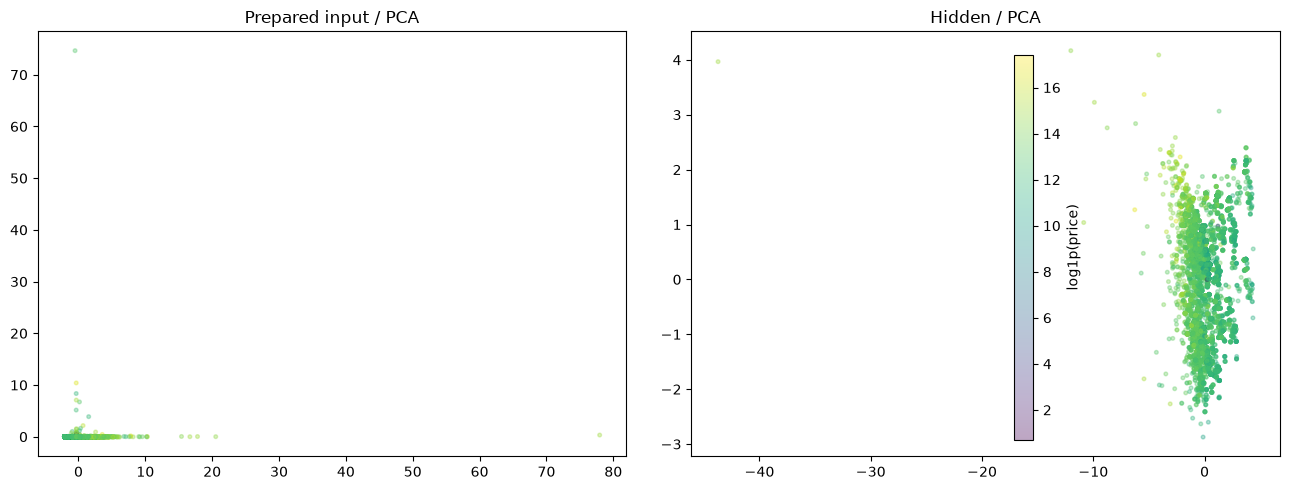

In [18]:
def extract_hidden_dense(model,X_array,batch_size=1024):
    model.eval(); out=[]; loader=DataLoader(TensorDataset(torch.from_numpy(np.asarray(X_array,dtype=np.float32))),batch_size=batch_size)
    with torch.no_grad():
        for (X_b,) in loader: out.append(model(X_b.to(device),return_hidden=True)[1].cpu().numpy())
    return np.vstack(out)
H_train=extract_hidden_dense(final_mlp,X_train); H_val=extract_hidden_dense(final_mlp,X_val)
rng=np.random.default_rng(RANDOM_STATE); idx=rng.choice(len(X_val),min(10_000,len(X_val)),replace=False); H_sample=H_val[idx]
input_2d=PCA(2,random_state=RANDOM_STATE).fit_transform(X_val[idx]); hidden_2d=PCA(2,random_state=RANDOM_STATE).fit_transform(H_sample); colors=np.log1p(y_val_dollar.to_numpy()[idx])
fig,axes=plt.subplots(1,2,figsize=(13,5)); s0=axes[0].scatter(input_2d[:,0],input_2d[:,1],c=colors,s=7,alpha=.35,cmap="viridis"); axes[0].set_title("Prepared input / PCA"); axes[1].scatter(hidden_2d[:,0],hidden_2d[:,1],c=colors,s=7,alpha=.35,cmap="viridis"); axes[1].set_title("Hidden / PCA"); fig.colorbar(s0,ax=axes,label="log1p(price)")
plt.tight_layout(); save_figure(FIGURE_DIR/"input_vs_hidden_pca.png",dpi=160,bbox_inches="tight"); plt.show()

### Bằng chứng trực quan từ PCA

Prepared input bị chi phối bởi một số điểm cực trị dọc PC1/PC2, khiến phần lớn quan sát nén gần gốc. Hidden PCA thay đổi hình học và tạo vài dải/cụm, nhưng màu giá cao–thấp vẫn chồng lấn, không xuất hiện gradient mục tiêu sạch hay đơn điệu.

Vì vậy hình PCA chỉ cho thấy MLP biến đổi không gian, **chưa đủ chứng minh** representation đã tổ chức giá tốt hơn. Kết luận mạnh hơn phải dựa vào linear probe và metric, đồng thời nhớ rằng PCA 2D có thể bỏ mất thông tin ở các chiều còn lại.

### Linear Probe trên prepared input và frozen hidden

Cell fit cùng một Linear Regression trên hai biểu diễn, dùng train để fit và validation để đánh giá. MLP bị đóng băng; probe không cập nhật hidden layers. Cùng clipping audit được áp dụng để tránh so sánh thiếu minh bạch.

In [19]:
probe_rows=[]
for representation,A,B in [("Prepared input",X_train,X_val),("Frozen hidden",H_train,H_val)]:
    probe=LinearRegression().fit(A,y_train_model); probe_rows.append({"representation":representation,**regression_metrics(y_val_dollar,probe.predict(B))})
probe_results=pd.DataFrame(probe_rows); display(probe_results); report_clipping(probe_results, "Linear Probe / validation", "representation")

,representation,mae,mse,rmse,r2,raw_mae,raw_mse,raw_rmse,raw_r2,raw_metrics_valid,n_below,n_above,n_nonfinite,n_clipped,clip_rate,clip_lower_train_scale,clip_upper_train_scale
0,Prepared input,327404.313598,8.020761e+12,2.832095e+06,-6.060647,8.608371e+07,4.297405e+20,2.073018e+10,-3.782990e+08,True,0,9,0,9,0.00015,0.693147,19.174453
1,Frozen hidden,259461.475908,7.927412e+11,8.903601e+05,0.302153,2.594615e+05,7.927412e+11,8.903601e+05,3.021527e-01,True,0,0,0,0,0.00000,0.693147,19.174453


,representation,n_below,n_above,n_nonfinite,n_clipped,clip_rate,raw_metrics_valid
0,Prepared input,0,9,0,9,0.00015,True
1,Frozen hidden,0,0,0,0,0.00000,True


Linear Probe / validation: có prediction bị safeguard nhưng clip_rate của từng model không vượt 1%.


### Kết quả Linear Probe

Probe trên prepared input trùng hành vi Linear Regression baseline: safeguarded RMSE **2,832 triệu USD**, R² **−6,0606**, 9 prediction bị clip; raw RMSE khoảng **20,73 tỷ USD**. Probe trên frozen hidden đạt MAE **259.461 USD**, RMSE **890.360 USD**, R² **0,3022**, không clipping và raw=safeguarded.

Đây là bằng chứng định lượng mạnh rằng hidden representation làm target **dễ giải mã tuyến tính hơn** prepared input đối với split này. Tuy nhiên, nó không chứng minh từng neuron có ý nghĩa ngữ nghĩa, không bảo đảm tổng quát qua seed/dataset khác, và không thay đổi kết luận rằng Random Forest vẫn tốt hơn trên test.

## OPTIONAL – gradient norm và activation statistics

Diagnostic tùy chọn nhằm kiểm tra nhanh norm gradient và phân phối activation trên một batch. Nó không phải tiêu chí bắt buộc để chọn model và được tắt trong lần chạy chính để tránh thêm chi phí hoặc làm thay đổi trạng thái thí nghiệm.

### Diagnostic tùy chọn

Nếu bật, cell sao chép model đã chọn, chạy một batch, backpropagate và báo gradient norm cùng mean/std/sparsity của hidden activation. Dùng bản sao giúp tránh cập nhật hoặc làm bẩn gradient của model cuối.

In [20]:
if RUN_OPTIONAL_DIAGNOSTICS:
    diagnostic=copy.deepcopy(final_mlp).to(device).train(); X_b,y_b=next(iter(train_loader)); X_b,y_b=X_b.to(device),y_b.to(device); diagnostic.zero_grad(); output,hidden=diagnostic(X_b,return_hidden=True); nn.MSELoss()(output,y_b).backward()
    display(pd.DataFrame([{"parameter":n,"gradient_norm":p.grad.norm().item()} for n,p in diagnostic.named_parameters() if p.grad is not None])); print("Zero activation fraction:",(hidden==0).float().mean().item())
else: print("Bỏ qua diagnostics; bật RUN_OPTIONAL_DIAGNOSTICS nếu cần.")

Bỏ qua diagnostics; bật RUN_OPTIONAL_DIAGNOSTICS nếu cần.


### Trạng thái diagnostic

Output xác nhận `RUN_OPTIONAL_DIAGNOSTICS=False`, nên không có số liệu gradient/activation thực tế để phân tích. Không nên suy diễn về vanishing gradient, exploding gradient hay sparsity từ một nhánh chưa chạy.

### Lưu artifact

Cell chỉ lưu artifact khi không ở QUICK mode. Artifact gồm preprocessor, cấu hình/weights MLP và các bảng kết quả cần thiết để tái sử dụng; việc lưu không thay thế yêu cầu tái lập môi trường và code preprocessing.

In [21]:
if QUICK_MODE:
    print("QUICK_MODE: không lưu result/model artifact final.")
else:
    baseline_val_results.to_csv(RESULT_DIR/"house_baseline_validation.csv",index=False); mlp_experiment_results.to_csv(RESULT_DIR/"house_mlp_experiments.csv",index=False); model_comparison.to_csv(RESULT_DIR/"house_model_comparison.csv",index=False)
    pd.concat([h.assign(experiment=n) for n,h in mlp_histories.items()],ignore_index=True).to_csv(RESULT_DIR/"house_training_history.csv",index=False)
    torch.save({"model_state":final_mlp.state_dict(),"input_dim":X_train.shape[1],"hidden_dims":list(final_mlp.hidden_dims),"output_dim":1,"target_mean":target_mean,"target_std":target_std,"use_log_target":USE_LOG_TARGET,"experiment":best_name},MODEL_DIR/"final_mlp.pt"); joblib.dump(preprocessor,MODEL_DIR/"preprocessor.joblib"); print("Đã lưu",RESULT_DIR)


Đã lưu E:\WINDOW\Project\intelligent-system-assignment-01\results\assignment03


### Artifact của lần chạy FULL

Output cho biết các artifact final đã được lưu. Chúng gắn với split, feature schema, target transform và bounds train của lần chạy này; sử dụng model mà không đi kèm đúng preprocessor hoặc inverse logic sẽ tạo prediction không tương thích.

### Tóm tắt tự động cuối notebook

Cell in mô hình thắng, đối chiếu MLP với traditional baseline tốt nhất, parameter/time và clipping summary. Đây là bản tóm tắt từ bảng kết quả đã tính, còn diễn giải khoa học phải giữ các giới hạn về sample, một split và safeguard.

In [22]:
clip_summary=model_comparison.set_index("model")["clip_rate"]
best=model_comparison.sort_values("rmse").iloc[0]; mlp=model_comparison[model_comparison.learned_representation].iloc[0]; trad=model_comparison[~model_comparison.learned_representation].sort_values("rmse").iloc[0]
display(Markdown(f"""## Kết luận dựa trên kết quả đã chạy

- RMSE test sau safeguard thấp nhất: **{best['model']}**, ${best['rmse']:,.0f}, clip_rate={best['clip_rate']:.4%}.
- Final MLP RMSE sau safeguard=${mlp['rmse']:,.0f}, clip_rate={mlp['clip_rate']:.4%}; traditional tốt nhất {trad['model']} RMSE=${trad['rmse']:,.0f}, clip_rate={trad['clip_rate']:.4%}.
- MLP train {mlp['training_seconds']:.1f}s với {int(mlp['parameter_count']):,} parameters.
- Các metric trên chỉ phản ánh raw predictions hoàn toàn khi clip_rate=0; nếu không, phải đối chiếu raw_* và raw_metrics_valid trước khi kết luận.
- Cần kết hợp MAE, residual theo price range, PCA/probe và giới hạn feature địa lý để đánh giá tính thực tiễn.
"""))

## Kết luận dựa trên kết quả đã chạy

- RMSE test sau safeguard thấp nhất: **Random Forest Regressor**, $843,020, clip_rate=0.0000%.
- Final MLP RMSE sau safeguard=$1,289,163, clip_rate=0.0017%; traditional tốt nhất Random Forest Regressor RMSE=$843,020, clip_rate=0.0000%.
- MLP train 311.5s với 4,033 parameters.
- Các metric trên chỉ phản ánh raw predictions hoàn toàn khi clip_rate=0; nếu không, phải đối chiếu raw_* và raw_metrics_valid trước khi kết luận.
- Cần kết hợp MAE, residual theo price range, PCA/probe và giới hạn feature địa lý để đánh giá tính thực tiễn.


### Kết luận thực nghiệm

Dữ liệu thô có **2.226.382** dòng; toàn bộ so sánh dùng mẫu tái lập **400.000** dòng với sáu raw feature, sau preprocessing thành `d=61`. Split là **280.000/60.000/60.000**. Imputation, scaling, OHE, chuẩn hóa log-target và clipping bounds đều học từ train.

Trên validation, Random Forest là traditional model tốt nhất (MAE 227.886; RMSE 816.411; R² 0,4133). Baseline MLP `61→64→1`, Adam `lr=1e-3`, batch 512 có 4.033 tham số, best epoch 26, chạy 311,5 s và đạt RMSE 892.011. Hai mạng sâu 6.081 tham số đạt RMSE 895.948 (`lr=1e-3`) và 896.858 (`lr=3e-4`): thêm layer hoặc giảm learning rate không cải thiện tiêu chí chọn. Baseline được khóa bằng validation RMSE rồi MAE.

Trên test, MLP cuối có MAE **265.721 USD**, RMSE **1,289 triệu USD**, R² **−0,4135**; `raw_metrics_valid=True`, raw RMSE 2,343 triệu và raw R² −3,6707. Random Forest thắng cả MAE **228.400**, RMSE **843.020** và R² **0,3955**; Decision Tree đứng thứ hai, Linear Regression ngoại suy rất bất thường. RF/Tree không clip, MLP clip 1/60.000 (0,001667%), Linear clip 12/60.000 (0,02%). Dù dưới ngưỡng cảnh báo 1%, clipping đã tác động đáng kể metric bình phương của MLP/Linear.

Representation learning có tín hiệu định lượng: frozen-hidden probe đạt RMSE 890.360 và R² 0,3022, vượt xa prepared-input probe; nhưng PCA 2D không cho gradient giá sạch và end-to-end MLP vẫn thua mô hình cây. Error analysis cho thấy quintile giá cao nhất khó nhất và một số feature/price cực trị chi phối RMSE.

Giới hạn chính: chỉ huấn luyện trên mẫu 400K thay vì toàn bộ 2,226M dòng; bỏ các biến địa lý/định danh cardinality cao; missingness lớn và imputation đơn giản; target/outlier rất heavy-tailed; một split seed 42; chỉ ba cấu hình MLP và hai learning rate; không chạy seed stability; clipping là post-processing có ảnh hưởng; timing chỉ đại diện CPU đã dùng; PCA 2D và linear probe không chứng minh semantic meaning hay generalization ngoài tập này.

## Checklist sau lần chạy FULL

- [x] Quét đủ 2.226.382 dòng và huấn luyện trên mẫu tái lập 400.000 dòng.
- [x] Dùng đúng feature: `bed`, `bath`, `acre_lot`, `house_size`, `state`, `status`; target `price`.
- [x] Split 70/15/15; preprocessing, target scaling và clipping bounds chỉ học từ train.
- [x] So sánh Linear Regression, Decision Tree, Random Forest và ba cấu hình MLP.
- [x] Chọn Baseline MLP chỉ bằng validation; test dùng một lần cho đánh giá cuối.
- [x] Báo MAE, MSE, RMSE, R² cùng raw metrics và clipping audit.
- [x] Phân tích learning curves, error theo price quintile, PCA và Linear Probe.
- [ ] Chưa chạy optional gradient/activation diagnostic hoặc seed-stability; kết luận không giả định các bằng chứng này tồn tại.

**Kết luận ngắn:** Random Forest thắng trên test; hidden representation dễ giải mã tuyến tính hơn prepared input, nhưng MLP end-to-end chưa cạnh tranh được với mô hình cây. Train-range clipping là safeguard có ảnh hưởng thực tế đến metric, dù số mẫu bị clip rất nhỏ.